In [14]:
# Environment check: confirm the notebook runs on paper2_env (Python 3.9),
# not the system Python. Should print a path containing "paper2_env".
import sys
print(sys.executable)

/opt/miniconda3/envs/paper2_env/bin/python3.9


In [68]:
# Config check: confirm config.py loads and its settings are readable.
# If this errors with "no attribute", restart the kernel (Kernel > Restart).
import importlib, config
importlib.reload(config)
print(config.DATASETS["uavcan"])
print(config.SEED, config.TOP_K)

/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAVCAN/processed_UAVCAN.csv
42 5


In [20]:
# Inspect raw UAVCAN data: shape, columns, label values, missing values

# how many rows/columns, the column names, 
# what the label values look like (numbers? text?), 
# and whether there are missing values to clean. 

import pandas as pd, config
df = pd.read_csv(config.DATASETS["uavcan"])
print("shape:", df.shape)
print("columns:", list(df.columns))
print("label values:", df["label"].unique())
print("missing values:", df.isna().sum().sum())

shape: (2032530, 11)
columns: ['CAN_ID', 'DLC', 'byte0', 'byte1', 'byte2', 'byte3', 'byte4', 'byte5', 'byte6', 'byte7', 'label']
label values: [1 0]
missing values: 0


In [71]:
# Test data_loader on UAVCAN: load, clean, scale, split.
# Confirms train/test shapes (should be 70/30),
# feature names, and class balance in the training set.

import numpy as np
import importlib, data_loader
importlib.reload(config)  
importlib.reload(data_loader)

X_train, X_test, y_train, y_test, feat = data_loader.load_dataset("uavcan")
print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print("features:", feat)
print("label balance:", dict(zip(*np.unique(y_train, return_counts=True))))

train shape: (1422771, 10)
test shape: (609759, 10)
features: ['CAN_ID', 'DLC', 'byte0', 'byte1', 'byte2', 'byte3', 'byte4', 'byte5', 'byte6', 'byte7']
label balance: {0: 529561, 1: 893210}


In [72]:
# Test data_loader on all 3 datasets at once.
# Confirms each loads cleanly and shows shape, feature count, and class set.
# Note the differences: uavcan=binary, isot=10 classes, uav_attack=3 classes.

for name in ["uavcan", "isot", "uav_attack"]:
    Xtr, Xte, ytr, yte, feat = data_loader.load_dataset(name)
    print(f"{name:12} train={Xtr.shape}  test={Xte.shape}  n_features={len(feat)}  classes={set(ytr)}")

uavcan       train=(1422771, 10)  test=(609759, 10)  n_features=10  classes={0, 1}
isot         train=(205671, 61)  test=(88145, 61)  n_features=61  classes={0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
uav_attack   train=(7046, 80)  test=(3021, 80)  n_features=80  classes={0, 1, 2}


In [28]:
# Verify benign labels match the CSVs: print label counts per dataset
# and the benign label set in config. Confirms benign points to a real,
# majority-normal class (uavcan=1, isot=0, uav_attack=2).

import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
import pandas as pd

for name in ["uavcan", "isot", "uav_attack"]:
    df = pd.read_csv(config.DATASETS[name])
    print(name, "label counts:", df["label"].value_counts().to_dict())
    print("   benign set to:", config.BENIGN_LABEL[name])

uavcan label counts: {1: 1276014, 0: 756516}
   benign set to: 1
isot label counts: {0: 128069, 1: 121244, 6: 23122, 4: 10514, 9: 7723, 3: 973, 5: 610, 7: 586, 8: 501, 2: 474}
   benign set to: 0
uav_attack label counts: {2: 8109, 0: 1460, 1: 498}
   benign set to: 2


In [31]:
# Train all 4 models on uav_attack (smallest dataset, fastest to test).
# AE and Isolation Forest take the dataset name so they use the correct
# benign label for training on normal traffic only.

import models
importlib.reload(models)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf  = models.build_random_forest(Xtr, ytr)
cnn = models.build_cnn(Xtr, ytr)
ae  = models.build_autoencoder(Xtr, ytr, "uav_attack")
iso = models.build_isolation_forest(Xtr, ytr, "uav_attack")
print("all four trained")

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9173 - loss: 0.2686 - val_accuracy: 1.0000 - val_loss: 8.9431e-04
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9988 - loss: 0.0048 - val_accuracy: 0.9988 - val_loss: 0.0010
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9995 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 1.4127e-04
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 3.1931e-04
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 1.7292e-04
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.4303 - val_loss: 0.3882
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3850 - val_loss: 0.3451
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3381 - val_loss: 0.2792
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2627 - val_loss: 0.2131
Epoch 5/10


In [9]:
# load_dataset reads the CSV, drops bad rows, separates features from the
# label, scales everything, and splits 70/30. It hands back 5 things:
# training and test features, training and test labels, and feature names.

import importlib, config, data_loader, models, metrics             # import the 4 modules
for m in(config, data_loader, models, metrics): importlib.reload(m) # forcing python to re-read them from disk

# Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack") -> below is for this line function:
# load_dataset function for eading the CSV drops bad rows, seperates features from the label, scales everthing, and splits 70/30. 
# it hands back 5 things: training and test features, traiing and test labels and feature names
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf = models.build_random_forest(Xtr, ytr)                   # RF and cnn only need features and labels (supervised)
cnn = models.build_cnn(Xtr, ytr)
ae = models.build_autoencoder(Xtr, ytr,"uav_attack")       # AE and Isolation Forest are unsupervised, both train on normal traffic only
iso = models.build_isolation_forest(Xtr, ytr, "uav_attack")

# below is evaluate and print above out:
"""
evaluate_supervised -> RF, CNN = both predict classes — same logic, one flag for CNN's reshape
evaluate_autoencoder -> AE = needs MSE + threshold conversion
evaluate_isolation_forest -> IF = needs +1/−1 conversion
"""
print("RF :", metrics.evaluate_supervised(rf, Xte, yte))                      # rf and cnn are share same function 
print("CNN:", metrics.evaluate_supervised(cnn, Xte, yte, is_cnn=True))        # only cnn needs are reshape and an argmax which the is_cnn=True flag handles
print("AE :", metrics.evaluate_autoencoder(ae, Xte, yte, "uav_attack"))       # ae outputs a reconstruction error, iso outputs +1 or -1 directly (inlier/outlier)
print("IF :", metrics.evaluate_isolation_forest(iso, Xte, yte, "uav_attack")) # ae and iso is not share a function



Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8435 - loss: 0.3313 - val_accuracy: 0.9988 - val_loss: 0.0018
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9981 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 2.8796e-04
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9985 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 3.3805e-04
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 4.5922e-04
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 3.2157e-04
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.4490 - val_loss: 0.4010
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4000 - val_loss: 0.3593
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3499 - val_loss: 0.2967
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2855 - val_loss: 0.2307
Epoch 5/10

In [74]:
# Test SHAP on Random Forest. Returns (importance, all_zero) after the
# return-type standardization. top-5 by absolute SHAP magnitude.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf = models.build_random_forest(Xtr, ytr)

X_sample = Xte[:config.SHAP_SAMPLES_RF]
imp, all_zero = xai.shap_random_forest(rf, X_sample, feat) # two values

print("all_zero:", all_zero, "| shape:", imp.shape)
top5 = np.argsort(imp)[::-1][:5]
print("top 5 features:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

all_zero: False | shape: (80,)
top 5 features:
  eph_y: 0.024562
  noise_per_ms: 0.020652
  epv_y: 0.016969
  s_variance_m_s: 0.016265
  evh: 0.014976


In [77]:
# Test SHAP on CNN (GradientExplainer, needs 3D input + background data).
# Returns (importance, all_zero). Retrains CNN each run (~20s).
# The Keras UserWarning about input structure is harmless (Paper 1 showed it too).

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)

X_sample = Xte[:config.SHAP_SAMPLES_CNN]    # 100 samples
X_bg     = Xtr[:config.SHAP_BACKGROUND]     # 50 background samples

imp,all_zero = xai.shap_cnn(cnn, X_sample, X_bg, feat)

print("shape:", imp.shape, "(should be", len(feat), "features)")
top5 = np.argsort(imp)[::-1][:5]
print("top 5 features:")
for i in top5:
    print(f" {feat[i]}: {imp[i]:.6f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.8615 - loss: 0.3417 - val_accuracy: 0.9957 - val_loss: 0.0091
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.9977 - loss: 0.0088 - val_accuracy: 0.9957 - val_loss: 0.0084
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9995 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9993 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 6.0334e-04


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_115
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_115
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


shape: (80,) (should be 80 features)
top 5 features:
 noise_per_ms: 0.022641
 epv_y: 0.021952
 epv: 0.013757
 evh: 0.013540
 eph: 0.012921


In [78]:
# Test SHAP on Autoencoder (KernelExplainer via reconstruction-error wrapper).
# SLOWEST method: ~5 min on 50 samples, because KernelExplainer runs the
# AE thousands of times. Returns (importance, all_zero).
# Explains only 50 samples (SHAP_SAMPLES_AE) - the full test set would take hours.

import numpy as np # for mathematical calculations, for sortting features importance scores
# importlib for reload a modules.
import importlib, config, data_loader, models, metrics, xai

# reload every new modules, otherwise jupyter may still run old code that from paper 1
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

# loading the dataset.
# Xtr = training features, Xte = test features, ytr = training labels, yte = test labels, feat = feature names
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")

# ae learning only normal traffic
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

X_sample = Xte[:config.SHAP_SAMPLES_AE]  # shap is expensive, we test dataset 15000, but explain only first 50 samples
X_bg = Xtr[:config.SHAP_BACKGROUND]     # 50 background samples

imp, all_zero = xai.shap_autoencoder(ae, X_sample, X_bg, feat) # run shap and ask: which features were most important?

print("shape:", imp.shape,"(should be", len(feat), "features)") # check result: imp.shape shows how many importance scores we received
top5 = np.argsort(imp)[::-1][:5] # show results and sort it from smallest -> largest
print("top 5 features: ")
for i in top5:
    print(f" {feat[i]}: {imp[i]:.6f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.4463 - val_loss: 0.3947
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4053 - val_loss: 0.3711
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3817 - val_loss: 0.3311
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3374 - val_loss: 0.2758
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2748 - val_loss: 0.2146
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2184 - val_loss: 0.1665
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1732 - val_loss: 0.1401
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1486 - val_loss: 0.1260
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1306 - val_loss: 0.1173
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1205 - val_loss: 0.1106


  0%|          | 0/50 [00:00<?, ?it/s]

shape: (80,) (should be 80 features)
top 5 features: 
 xy_valid: 0.084000
 v_xy_valid: 0.079071
 q[3]: 0.072979
 vdop: 0.062434
 q[1]: 0.060811


In [79]:
# Test SHAP on Isolation Forest (KernelExplainer via anomaly-score wrapper).
# Faster than AE SHAP (~40s) because tree scoring is cheap. Returns (importance, all_zero).

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
iso = models.build_isolation_forest(Xtr, ytr, "uav_attack")

X_sample = Xte[:config.SHAP_SAMPLES_AE]  #  50 samples (KernelExplainer is slow)
X_bg = Xtr[:config.SHAP_BACKGROUND]      # 50 background samples

imp,all_zero = xai.shap_isolation_forest(iso, X_sample, X_bg, feat)

print("shape:", imp.shape, "(should be", len(feat), "features)")
top5 = np.argsort(imp)[::-1][:5]
print("top 5 features:")
for i in top5:
    print(f" {feat[i]}: {imp[i]:.6f}")

  0%|          | 0/50 [00:00<?, ?it/s]

shape: (80,) (should be 80 features)
top 5 features:
 s_variance_m_s: 0.010221
 evh: 0.007638
 vdop: 0.006385
 eph: 0.006241
 vel_n_m_s: 0.005965


In [80]:
# Test PI on Random Forest. Expect all_zero=True: RF hits 100% F1, so
# shuffling any single feature doesn't drop the score -> PI measures nothing.
# This is a documented finding: PI is uninformative for models at ceiling.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf = models.build_random_forest(Xtr, ytr)

# expect: all_zero = true (RF is at 100# f1, paper 1 saw the same)
imp, all_zero = xai.pi_random_forest(rf, Xte, yte, feat, n_repeats = 10)
print("all zero:", all_zero)
print("max importance:", imp.max())
print("non-zero features:", np.sum(imp !=0))

all zero: True
max importance: 0.0
non-zero features: 0


In [81]:
# Test PI on CNN (manual implementation - sklearn can't handle Keras).
# WARNING: slowest method, ~8 min at n_repeats=10.
# Note: CNN hit 100% F1, so PI returned all_zero=True here too - same as RF.
# (Paper 1's CNN was 99.97% and got small non-zero values; our 100% gives zeros.)

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)

# expect: all_zero = False, small non-zero values (~0.001-0.01)
# Paper 1 top features: vel_m_s, vel_n_m_s, hdop, evv, jamming_indicator
imp, all_zero = xai.pi_cnn(cnn, Xte, yte, feat, n_repeats=10)

print("all_zero:", all_zero)
print("max importance:", imp.max())
print("non-zero features:", np.sum(imp != 0))
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8072 - loss: 0.4081 - val_accuracy: 0.9957 - val_loss: 0.0126
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9995 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9990 - loss: 0.0049 - val_accuracy: 0.9986 - val_loss: 0.0019
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 9.4144e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 6.2856e-04
all_zero: False
max importance: 0.004295851615030466
non-zero features: 37
top 5:
  vel_m_s: 0.004296
  hdop: 0.003916
  vel_n_m_s: 0.003468
  vdop: 0.001618
  q[2]: 0.001347


In [82]:
# Test PI on Autoencoder (~3 min). The AE is at ~90% F1, well below ceiling,
# so PI IS informative here - unlike RF. Converts reconstruction error to a
# binary prediction via the 95th-percentile threshold, then shuffles features.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

# expect: all_zero = False (AE is at 90% F1, so there IS room to drop)
# Paper 1 top features: lat_x, lat_y, x, q[3], q[2]  (position coordinates)
imp, all_zero = xai.pi_autoencoder(ae, Xte, yte, feat, "uav_attack", n_repeats=10)

print("all_zero:", all_zero)
print("max importance:", imp.max())
print("non-zero features:", np.sum(imp != 0))
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.4315 - val_loss: 0.3783
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3931 - val_loss: 0.3404
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3516 - val_loss: 0.2861
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2921 - val_loss: 0.2250
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2288 - val_loss: 0.1746
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1859 - val_loss: 0.1494
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1609 - val_loss: 0.1359
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1467 - val_loss: 0.1271
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1380 - val_loss: 0.1203
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1266 - val_loss: 0.1144
all_zero: False
max importance: 0.06808592381770637
non-zero features: 64
top 5:
  dist_bottom_valid: 0.068086
  terrain_alt_valid: 0.065986
  terrai

In [84]:
# ae n-repeats = 10
# Sensitivity check: AE PI at n_repeats=5 vs the 10-repeat run above.
# If the top-5 is similar, 5 repeats is enough - justifies the faster setting.
# NOTE: this cell retrains the AE, so results mix "fewer repeats" with a new
# model. For a clean comparison, reuse the same ae from the n_repeats=10 cell.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

# expect: all_zero = False (AE is at 90% F1, so there IS room to drop)
# Paper 1 top features: lat_x, lat_y, x, q[3], q[2]  (position coordinates)
imp, all_zero = xai.pi_autoencoder(ae, Xte, yte, feat, "uav_attack", n_repeats=10)

print("all_zero:", all_zero)
print("max importance:", imp.max())
print("non-zero features:", np.sum(imp != 0))
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.4345 - val_loss: 0.3835
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3986 - val_loss: 0.3492
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3610 - val_loss: 0.2983
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3054 - val_loss: 0.2379
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2480 - val_loss: 0.1892
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1955 - val_loss: 0.1559
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1676 - val_loss: 0.1361
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1446 - val_loss: 0.1235
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1298 - val_loss: 0.1141
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1186 - val_loss: 0.1064
all_zero: False
max importance: 0.06709702563662348
non-zero features: 64
top 5:
  dist_bottom_valid: 0.067097
  terrain_alt: 0.064037
  terrain_alt_

In [83]:
# ae n-repeats = 5
# Sensitivity check: AE PI at n_repeats=5 vs the 10-repeat run above.
# If the top-5 is similar, 5 repeats is enough - justifies the faster setting.
# NOTE: this cell retrains the AE, so results mix "fewer repeats" with a new
# model. For a clean comparison, reuse the same ae from the n_repeats=10 cell.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

# expect: all_zero = False (AE is at 90% F1, so there IS room to drop)
# Paper 1 top features: lat_x, lat_y, x, q[3], q[2]  (position coordinates)
imp5, all_zero5 = xai.pi_autoencoder(ae, Xte, yte, feat, "uav_attack", n_repeats=5)

print("all_zero:", all_zero5)
print("max importance:", imp5.max())
print("non-zero features:", np.sum(imp5 != 0))
top5_new = np.argsort(imp5)[::-1][:5]
print("n_repeats=5 top 5:")
print("top 5:")
for i in top5_new:
    print(f"  {feat[i]}: {imp5[i]:.6f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.4458 - val_loss: 0.3947
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4104 - val_loss: 0.3659
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3741 - val_loss: 0.3208
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3199 - val_loss: 0.2500
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2496 - val_loss: 0.1848
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1882 - val_loss: 0.1497
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1569 - val_loss: 0.1305
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1382 - val_loss: 0.1203
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1246 - val_loss: 0.1132
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1162 - val_loss: 0.1074
all_zero: False
max importance: 0.0674966697143835
non-zero features: 64
n_repeats=5 top 5:
top 5:
  terrain_alt: 0.067497
  dist_bottom_valid: 0.065

In [85]:
# Test PI on Isolation Forest. Returns (importance, all_zero).
# NOTE: earlier this returned all-zeros due to a bug (predicted on X_sample
# instead of the shuffled X_perm). Fixed -> now 60 non-zero features.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
iso = models.build_isolation_forest(Xtr, ytr, "uav_attack")

# expect: all_zero = False (IF is at 79% F1, plenty of room to drop)
# no Paper 1 baseline - new model
imp, all_zero = xai.pi_isolation_forest(iso, Xte, yte, feat, "uav_attack", n_repeats=10)

print("all_zero:", all_zero)
print("max importance:", imp.max())
print("non-zero features:", np.sum(imp != 0))
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

all_zero: False
max importance: 0.025881407015146896
non-zero features: 60
top 5:
  evv: 0.025881
  delta_q_reset[1]: 0.025740
  q[3]: 0.024076
  heading_y: 0.021745
  eph_x: 0.019490


In [86]:
# Test LIME on Random Forest (default n_samples=50 now).
# Returns (importance, all_zero) - standardized like the other methods.
# LIME picks position/velocity features (lat_y, satellites_used) - notably
# different from SHAP's GPS-error features. That SHAP-vs-LIME divergence is
# a key thing ESS will measure.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf = models.build_random_forest(Xtr, ytr)

imp, all_zero = xai.lime_random_forest(rf, Xtr, Xte, feat)   # two values now
print("all_zero:", all_zero, "| shape:", imp.shape)
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

all_zero: False | shape: (80,)
top 5:
  lat_y: 0.064372
  satellites_used: 0.026687
  vel_n_m_s: 0.025474
  hdop: 0.022868
  lat_x: 0.018657


In [87]:
# Test LIME on CNN (wrapper reshapes 2D->3D). Returns (importance, all_zero).
# CNN LIME favours terrain/position features, diverging from CNN SHAP's
# GPS-error features - the SHAP-vs-LIME split shows up on the CNN too.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)

imp, all_zero = xai.lime_cnn(cnn, Xtr, Xte, feat)   # two values, default n_samples=50
print("all_zero:", all_zero, "| shape:", imp.shape)
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.8914 - loss: 0.3510 - val_accuracy: 0.9972 - val_loss: 0.0065
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9992 - loss: 0.0086 - val_accuracy: 0.9972 - val_loss: 0.0045
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 9.6525e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9990 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 9.3479e-04
all_zero: False | shape: (80,)
top 5:
  terrain_alt: 0.145004
  dist_bottom_valid: 0.137248
  vel_m_s: 0.107022
  lat_y: 0.095870
  satellites_used: 0.082889


In [88]:
# Test LIME on Autoencoder (needs threshold to convert MSE->probability).
# Returns (importance, all_zero). AE LIME tends to agree more with AE PI
# (both perturbation-based) than with AE SHAP.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")   # train it in this cell

ae_res = metrics.evaluate_autoencoder(ae, Xte, yte, "uav_attack")
threshold = ae_res["threshold"]
print("threshold:", threshold)

imp, all_zero = xai.lime_autoencoder(ae, Xtr, Xte, feat, threshold)   # two values, default 50
print("all_zero:", all_zero, "| shape:", imp.shape)
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.4442 - val_loss: 0.3875
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3994 - val_loss: 0.3476
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3528 - val_loss: 0.2902
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2965 - val_loss: 0.2246
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2267 - val_loss: 0.1736
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1817 - val_loss: 0.1438
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1518 - val_loss: 0.1288
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1384 - val_loss: 0.1198
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1261 - val_loss: 0.1126
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1160 - val_loss: 0.1065
threshold: 0.28545385704715903
all_zero: False | shape: (80,)
top 5:
  dist_bottom_valid: 0.021078
  terrain_alt: 0.019731
  terrain_alt_valid: 0.019

In [89]:
# Test LIME on Isolation Forest. Returns (importance, all_zero).
# NOTE: IF PI is NOT all-zeros anymore (that was the X_sample/X_perm bug).
# So IF has 3 usable methods (SHAP, PI, LIME), not 2. Update earlier notes.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
iso = models.build_isolation_forest(Xtr, ytr, "uav_attack")

imp, all_zero = xai.lime_isolation_forest(iso, Xtr, Xte, feat)   # two values, default 50
print("all_zero:", all_zero, "| shape:", imp.shape)
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

all_zero: False | shape: (80,)
top 5:
  terrain_alt_valid: 0.013702
  dist_bottom_valid: 0.012526
  terrain_alt: 0.010211
  vdop: 0.008828
  s_variance_m_s: 0.007815


In [90]:
# Test IG on CNN (gradient-based, neural only). Returns (importance, all_zero).
# Fixed-class version. IG is gradient-based like SHAP - check if it lands
# nearer SHAP (GPS-error features) than LIME (terrain features).
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)

imp, all_zero = xai.ig_cnn(cnn, Xte[:100], feat, n_steps=50)
print("all_zero:", all_zero, "| max importance:", imp.max())
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f"  {feat[i]}: {imp[i]:.6f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8362 - loss: 0.3840 - val_accuracy: 0.9957 - val_loss: 0.0137
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9985 - loss: 0.0089 - val_accuracy: 0.9972 - val_loss: 0.0061
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9987 - loss: 0.0077 - val_accuracy: 0.9972 - val_loss: 0.0063
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9988 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 8.4129e-04
all_zero: False | max importance: 0.0340723773278296
top 5:
  noise_per_ms: 0.034072
  epv_y: 0.029828
  satellites_used: 0.029670
  jamming_indicator: 0.028558
  eph: 0.023133


In [67]:
# Test IG on Autoencoder (gradient-based, attributes reconstruction-error MSE).
# Returns (importance, all_zero). Fast - no KernelExplainer.
# Two-camps check on AE:
#   AE SHAP: xy_valid, v_xy_valid, noise_per_ms, epv_y, y      (gradient camp)
#   AE PI:   dist_bottom_valid, terrain_alt_valid, terrain_alt, lat_y, x  (perturbation)
#   AE LIME: dist_bottom_valid, terrain_alt, terrain_alt_valid, noise_per_ms, q[2]  (perturbation)
# IG is gradient-based -> expect it near SHAP, far from PI/LIME.

import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

# AE SHAP: xy_valid, v_xy_valid, noise_per_ms, epv_y, y
# AE PIL dist_bottom_valid, terrain_alt_valid, terrain_alt, eph, lat_y
# AE LIME: terrain_alt, terrain_alt_valid, dist_bottom_valid, vel_m_s, noise_per_ms
# IG is gradient-based - expect it near SHAP, far from PI/LIME (the perturbation camp)
imp, all_zero = xai.ig_autoencoder(ae, Xte[:100], feat, n_steps=50)

print("all_zero:", all_zero)
print("max importance:", imp.max())
top5 = np.argsort(imp)[::-1][:5]
print("top 5:")
for i in top5:
    print(f" {feat[i]}: {imp[i]:.6f}")

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4395 - val_loss: 0.3985
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4010 - val_loss: 0.3680
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3665 - val_loss: 0.3238
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3146 - val_loss: 0.2668
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2547 - val_loss: 0.2094
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2007 - val_loss: 0.1638
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1621 - val_loss: 0.1345
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1321 - val_loss: 0.1178
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1185 - val_loss: 0.1081
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1091 - val_loss: 0.1014
all_zero: False
max importance: 0.03537055524005325
top 5:
 xy_valid: 0.035371
 v_xy_valid: 0.032887
 epv_y: 0.020338
 noise_per_ms: 0.017787
 eph_y: 

In [91]:
# Test ESS on the Autoencoder (the model with the most usable methods).
# Gather all 4 XAI outputs, feed them to compute_ess, check the pairwise
# Jaccards match what we computed by hand last session (SHAP-IG high,
# PI-LIME high, cross-camp near zero). SLOW: AE SHAP is ~5 min.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
ae = models.build_autoencoder(Xtr, ytr, "uav_attack")

# AE needs its threshold for the LIME wrapper
ae_res = metrics.evaluate_autoencoder(ae, Xte, yte, "uav_attack")
threshold = ae_res["threshold"]
X_bg = Xtr[:config.SHAP_BACKGROUND]

# collect all four methods as {name: (importance, all_zero)}
results = {
    "shap": xai.shap_autoencoder(ae, Xte[:config.SHAP_SAMPLES_AE], X_bg, feat),
    "lime": xai.lime_autoencoder(ae, Xtr, Xte, feat, threshold),
    "pi":   xai.pi_autoencoder(ae, Xte, yte, feat, "uav_attack", n_repeats=10),
    "ig":   xai.ig_autoencoder(ae, Xte[:100], feat, n_steps=50),
}

# compute ESS from those four
ess = metrics.compute_ess(results)
print("ESS:", ess["ess"])
print("methods used:", ess["methods_used"])
print("pairwise:")
for pair, j in ess["pairwise"].items():
    print(f"  {pair}: {j:.3f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.4571 - val_loss: 0.3999
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4182 - val_loss: 0.3807
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3971 - val_loss: 0.3545
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3629 - val_loss: 0.3109
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3192 - val_loss: 0.2592
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2663 - val_loss: 0.2161
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2245 - val_loss: 0.1813
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1909 - val_loss: 0.1561
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1671 - val_loss: 0.1376
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1459 - val_loss: 0.1230


  0%|          | 0/50 [00:00<?, ?it/s]

ESS: 0.12037037037037036
methods used: ['ig', 'lime', 'pi', 'shap']
pairwise:
  ('ig', 'lime'): 0.111
  ('ig', 'pi'): 0.250
  ('ig', 'shap'): 0.111
  ('lime', 'pi'): 0.250
  ('lime', 'shap'): 0.000
  ('pi', 'shap'): 0.000


In [92]:
# Test ESS on Random Forest. RF is stable (deterministic, 100% F1), so unlike
# the AE its ESS should be reproducible run-to-run.
# Note: RF has NO IG (trees have no gradients), and PI is likely all-zeros
# (perfect model). So compute_ess may end up with just SHAP + LIME = 2 methods,
# giving a single pairwise Jaccard. Expected low (SHAP picks GPS-error features,
# LIME picks position features - they disagreed last session).
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
rf = models.build_random_forest(Xtr, ytr)

X_bg = Xtr[:config.SHAP_BACKGROUND]

# RF gets 3 candidate methods (no IG). compute_ess drops any that are all_zero.
results = {
    "shap": xai.shap_random_forest(rf, Xte[:config.SHAP_SAMPLES_RF], feat),
    "lime": xai.lime_random_forest(rf, Xtr, Xte, feat),
    "pi":   xai.pi_random_forest(rf, Xte, yte, feat, n_repeats=10),
}

ess = metrics.compute_ess(results)
print("ESS:", ess["ess"])
print("methods used:", ess["methods_used"])
print("n_methods:", ess["n_methods"])
print("pairwise:")
for pair, j in ess["pairwise"].items():
    print(f"  {pair}: {j:.3f}")

ESS: 0.0
methods used: ['lime', 'shap']
n_methods: 2
pairwise:
  ('lime', 'shap'): 0.000


In [93]:
# Test ESS on CNN. Stable model (reproducible), and on 70/30 its PI is
# non-zero - so this may use all 4 methods (SHAP, LIME, PI, IG) = 6 pairs.
# That makes CNN the best-supported, most trustworthy ESS of the three models.
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)

X_bg = Xtr[:config.SHAP_BACKGROUND]

results = {
    "shap": xai.shap_cnn(cnn, Xte[:config.SHAP_SAMPLES_CNN], X_bg, feat),
    "lime": xai.lime_cnn(cnn, Xtr, Xte, feat),
    "pi":   xai.pi_cnn(cnn, Xte, yte, feat, n_repeats=10),
    "ig":   xai.ig_cnn(cnn, Xte[:100], feat, n_steps=50),
}

ess = metrics.compute_ess(results)
print("ESS:", ess["ess"])
print("methods used:", ess["methods_used"])
print("n_methods:", ess["n_methods"])
print("pairwise:")
for pair, j in ess["pairwise"].items():
    print(f"  {pair}: {j:.3f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8724 - loss: 0.3016 - val_accuracy: 0.9986 - val_loss: 0.0036
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9986 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 7.5163e-04
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 6.8847e-04
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9998 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 3.6107e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 1.6641e-04


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_177
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_177
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


ESS: 0.1130952380952381
methods used: ['ig', 'lime', 'pi', 'shap']
n_methods: 4
pairwise:
  ('ig', 'lime'): 0.000
  ('ig', 'pi'): 0.000
  ('ig', 'shap'): 0.429
  ('lime', 'pi'): 0.250
  ('lime', 'shap'): 0.000
  ('pi', 'shap'): 0.000


In [94]:
# Reproducibility check: re-run CNN ESS. If CNN is stable, expect ~ 0.113
# again and the same camp structure (SHAP-IG high, cross-camp  zeros)
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in(config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
cnn = models.build_cnn(Xtr, ytr)
X_bg = Xtr[:config.SHAP_BACKGROUND]

results = {
    "shap": xai.shap_cnn(cnn, Xte[:config.SHAP_SAMPLES_CNN], X_bg, feat),
    "lime": xai.lime_cnn(cnn, Xtr, Xte, feat),
    "pi":   xai.pi_cnn(cnn, Xte, yte, feat, n_repeats=10),
    "ig":   xai.ig_cnn(cnn, Xte[:100], feat, n_steps=50),
}

ess = metrics.compute_ess(results)
print("ESS:", ess["ess"])
print("methods used:", ess["methods_used"])
print("n_methods:", ess["n_methods"])
print("pairwise:")
for pair, j in ess["pairwise"].items():
    print(f"  {pair}: {j:.3f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.8498 - loss: 0.3541 - val_accuracy: 0.9972 - val_loss: 0.0051
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9981 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9992 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 9.5659e-04
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9987 - loss: 0.0038 - val_accuracy: 0.9986 - val_loss: 0.0027
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9991 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0011


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_185
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_185
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


ESS: 0.12698412698412698
methods used: ['ig', 'lime', 'pi', 'shap']
n_methods: 4
pairwise:
  ('ig', 'lime'): 0.111
  ('ig', 'pi'): 0.111
  ('ig', 'shap'): 0.429
  ('lime', 'pi'): 0.111
  ('lime', 'shap'): 0.000
  ('pi', 'shap'): 0.000


In [95]:
# Reproducibility check: run CNN ESS 3 times, collect the ESS values.
# Tests whether ESS is stable across CNN retraining (weight init, dropout vary).
import numpy as np
import importlib, config, data_loader, models, metrics, xai
for m in (config, data_loader, models, metrics, xai): importlib.reload(m)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_attack")
X_bg = Xtr[:config.SHAP_BACKGROUND]

ess_values = []
for run in range(3):
    cnn = models.build_cnn(Xtr, ytr)
    results = {
        "shap": xai.shap_cnn(cnn, Xte[:config.SHAP_SAMPLES_CNN], X_bg, feat),
        "lime": xai.lime_cnn(cnn, Xtr, Xte, feat),
        "pi":   xai.pi_cnn(cnn, Xte, yte, feat, n_repeats=10),
        "ig":   xai.ig_cnn(cnn, Xte[:100], feat, n_steps=50),
    }
    ess = metrics.compute_ess(results)
    ess_values.append(ess["ess"])
    print(f"run {run+1}: ESS = {ess['ess']:.4f}  (shap-ig = {ess['pairwise'].get(('ig','shap')):.3f})")

print(f"\nmean: {np.mean(ess_values):.4f}  min: {min(ess_values):.4f}  max: {max(ess_values):.4f}")

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8441 - loss: 0.3705 - val_accuracy: 0.9972 - val_loss: 0.0083
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 0.9986 - val_loss: 0.0026
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9996 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 5.7478e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9988 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 2.4814e-04


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_193
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_193
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


run 1: ESS = 0.1131  (shap-ig = 0.429)
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.8746 - loss: 0.3418 - val_accuracy: 0.9957 - val_loss: 0.0080
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9977 - loss: 0.0085 - val_accuracy: 0.9972 - val_loss: 0.0056
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 9.2767e-04
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 5.8192e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9998 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 4.0383e-04


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_201
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_201
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


run 2: ESS = 0.0972  (shap-ig = 0.250)
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8142 - loss: 0.3699 - val_accuracy: 0.9972 - val_loss: 0.0076
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9986 - loss: 0.0065 - val_accuracy: 0.9972 - val_loss: 0.0051
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9982 - loss: 0.0131 - val_accuracy: 0.9986 - val_loss: 0.0018
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9986 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 6.1267e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 3.3392e-04


/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_209
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_209
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


run 3: ESS = 0.1316  (shap-ig = 0.429)

mean: 0.1140  min: 0.0972  max: 0.1316


In [96]:
# ----------------------------------------------------------
# Test the Paper 2 pipeline on a single dataset
# Reload modules after code changes (useful for Jupyter development)
# Run the complete workflow: data loading, model training,
# ML evaluation, XAI explanations, and ESS calculation
# ----------------------------------------------------------

import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)

results = run.run_dataset("uav_attack")


DATASET: uav_attack
training models...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.8556 - loss: 0.3486 - val_accuracy: 0.9986 - val_loss: 0.0032
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 9.6314e-04
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9990 - loss: 0.0056 - val_accuracy: 0.9986 - val_loss: 0.0018
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.9991 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.8869e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 5.9598e-04
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.4583 - val_loss: 0.3987
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4123 - val_loss: 0.3731
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3885 - val_loss: 0.3432
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 

/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_217
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/paper2_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_217
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- uav_attack summary ---
  rf    F1=1.000  ESS=0.000 (2 methods)
  cnn   F1=1.000  ESS=0.132 (4 methods)
  ae    F1=0.903  ESS=0.169 (4 methods)
  iso   F1=0.772  ESS=0.083 (3 methods)


In [97]:
# Quick test of the JSON saving feature (no pipeline re-run needed).
# Uses the 'results' dict already in memory from the last run: saves it to
# results/results_uav_attack.json, then reads it back to confirm the
# _make_serializable conversion worked (numpy types + tuple keys -> JSON-safe).

import importlib, run
importlib.reload(run)
import json, os

# save the results dict you already have in memory
os.makedirs("results", exist_ok=True)
with open("results/results_uav_attack.json", "w") as f:
    json.dump(run._make_serializable(results), f, indent=2)

# read it back to confirm it saved correctly
with open("results/results_uav_attack.json") as f:
    loaded = json.load(f)
print("saved and reloaded OK")
print("models:", list(loaded["ess"].keys()))
print("cnn ESS:", loaded["ess"]["cnn"]["ess"])
print("cnn pairwise:", loaded["ess"]["cnn"]["pairwise"])

saved and reloaded OK
models: ['rf', 'cnn', 'ae', 'iso']
cnn ESS: 0.1316137566137566
cnn pairwise: {"('ig', 'lime')": 0.1111111111111111, "('ig', 'pi')": 0.0, "('ig', 'shap')": 0.42857142857142855, "('lime', 'pi')": 0.25, "('lime', 'shap')": 0.0, "('pi', 'shap')": 0.0}


In [101]:
# ==========================================================
# Verify CICIDS2017 Paper 1 Preprocessed Dataset Loading
#
# The CICIDS2017 dataset was preprocessed in Paper 1 and saved
# as ready-to-use train/test files:
# - Full cleaned dataset: 2,827,876 samples
# - Features: 80 numerical traffic features
# - Classes: 13 attack categories
# - StandardScaler already applied
# - Train/test split: 70% / 30%
# - Random state: 42
#
# This test confirms that Paper 2 loads the identical processed
# data instead of rebuilding the preprocessing pipeline.
#
# Expected:
# X_train: (1,979,513, 80)
# X_test : (848,363, 80)
# y_train: (1,979,513,)
# y_test : (848,363,)
# Features: 80
#
# The class distribution check verifies that all 13 encoded
# CICIDS2017 labels are preserved:
# 0 = BENIGN, ..., 12 = Web Attack
# ==========================================================
import importlib
import config
import data_loader

importlib.reload(config)
importlib.reload(data_loader)

X_train, X_test, y_train, y_test, features = data_loader.load_dataset("cicids")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(len(features))

print(np.unique(y_train, return_counts=True))

(1979513, 80)
(848363, 80)
(1979513,)
(848363,)
80
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), array([1589924,    1369,   89617,    7205,  161087,    3849,    4057,
          5555,       8,      25,  111163,    4128,    1526]))


In [102]:
# TEST 1: Confirm the XAI_TEST_CAP config value loads and the subsampling
# logic works on a CICIDS-sized array. No model training - instant check.
# Expect: XAI_TEST_CAP=3000, capped rows=3000, reproducible=True.
import importlib, config, run
importlib.reload(config); importlib.reload(run)
import numpy as np

print("XAI_TEST_CAP:", config.XAI_TEST_CAP)

# confirm the subsampling math works on CICIDS-sized data
fake_Xte = np.zeros((848363, 80))   # pretend CICIDS test set
cap = config.XAI_TEST_CAP
rng = np.random.RandomState(config.SEED)
idx = rng.choice(len(fake_Xte), cap, replace=False)
print("original rows:", len(fake_Xte))
print("capped rows:", len(idx))
print("reproducible?", (idx == np.random.RandomState(config.SEED).choice(848363, cap, replace=False)).all())

XAI_TEST_CAP: 3000
original rows: 848363
capped rows: 3000
reproducible? True


In [1]:
# Verify CICIDS loads with memory-safe subsampling (for 8GB RAM).
# Full CICIDS is 2.8M rows and crashes training; the loader subsamples to
# CICIDS_TRAIN_CAP (150K) / CICIDS_TEST_CAP (50K), stratified to keep all
# 13 classes. Confirms shapes shrank and no class was lost.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("cicids")
print("train shape:", Xtr.shape, "(should be ~150000)")
print("test shape:", Xte.shape, "(should be ~50000)")
import numpy as np
print("classes present:", sorted(set(ytr)))

train shape: (150000, 80) (should be ~150000)
test shape: (50000, 80) (should be ~50000)
classes present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [2]:
# TEST 2: Run CICIDS end-to-end on ONE model (RF, the fastest) to check the
# .npy loader branch works and how long capped XAI takes before committing to
# the full 4-model run. RF trains on full 1.98M rows (~1-2 min); XAI runs on
# the 3000-row cap (should be fast). Watch the per-method runtimes.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)
import time

# load CICIDS (uses the new .npy loader branch)
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("cicids")
print("loaded CICIDS:", Xtr.shape, Xte.shape)

# train just RF (fastest model) and time it
t0 = time.time()
rf = models.build_random_forest(Xtr, ytr)
print(f"RF trained in {time.time()-t0:.0f}s")

# run XAI for RF only - this exercises the subsampling cap
t0 = time.time()
xai_out, runtimes = run.run_xai_for_model("rf", rf, Xtr, Xte, ytr, yte, feat, "cicids")
print(f"RF XAI done in {time.time()-t0:.0f}s")
print("per-method runtimes:", runtimes)

# compute ESS for RF
ess = metrics.compute_ess(xai_out)
print("RF ESS:", ess["ess"], "| methods:", ess["methods_used"])

loaded CICIDS: (150000, 80) (50000, 80)
RF trained in 33s
RF XAI done in 322s
per-method runtimes: {'shap': 27.97, 'lime': 10.21, 'pi': 283.57}
RF ESS: 0.1574074074074074 | methods: ['lime', 'pi', 'shap']


In [9]:
# FULL CICIDS RUN (dataset 4 of 8): all 4 models on the 150K memory-safe subsample.
# CICIDS is 2.8M rows - subsampled to fit 8GB RAM (see data_loader cicids branch).
# Trains RF/CNN/AE/IF, runs all XAI, computes ML metrics + ESS, auto-saves to
# results/results_cicids.json. Takes ~15 min. Note: F1 won't exactly match Paper 1
# because of the subsampling - that's expected, noted in methodology.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)

results = run.run_dataset("cicids")


DATASET: cicids
training models...
Epoch 1/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 56s 103ms/step - accuracy: 0.9174 - loss: 0.3184 - val_accuracy: 0.9683 - val_loss: 0.0805
Epoch 2/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 57s 109ms/step - accuracy: 0.9672 - loss: 0.0849 - val_accuracy: 0.9743 - val_loss: 0.0630
Epoch 3/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.9716 - loss: 0.0683 - val_accuracy: 0.9739 - val_loss: 0.0571
Epoch 4/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 47s 89ms/step - accuracy: 0.9745 - loss: 0.0587 - val_accuracy: 0.9759 - val_loss: 0.0537
Epoch 5/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 46s 88ms/step - accuracy: 0.9763 - loss: 0.0552 - val_accuracy: 0.9751 - val_loss: 0.0540
Epoch 1/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9667 - val_loss: 0.2349
Epoch 2/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4809 - val_loss: 0.1628
Epoch 3/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3495 - val_loss: 0.1329
Epoch 4/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss:

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_26
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_26
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- cicids summary ---
  rf    F1=0.999  ESS=0.157 (3 methods)
  cnn   F1=0.976  ESS=0.233 (4 methods)
  ae    F1=0.575  ESS=0.144 (4 methods)
  iso   F1=0.511  ESS=0.143 (3 methods)


In [5]:
# Re-run uav_attack the clean automated way (via run.py), so its results are
# saved in the same JSON format as cicids. Earlier this dataset was built
# cell-by-cell during development; this gives one uniform result file for
# cross-dataset comparison. Fast (~5 min, only 7K rows).
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)

results = run.run_dataset("uav_attack")


DATASET: uav_attack
training models...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.9096 - loss: 0.3363 - val_accuracy: 0.9986 - val_loss: 0.0047
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9972 - val_loss: 0.0050
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9989 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9991 - loss: 0.0060 - val_accuracy: 0.9986 - val_loss: 0.0035
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9991 - loss: 0.0030 - val_accuracy: 0.9986 - val_loss: 0.0017
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.4522 - val_loss: 0.3933
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4093 - val_loss: 0.3666
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3819 - val_loss: 0.3293
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3401 - val

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_13
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_13
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- uav_attack summary ---
  rf    F1=1.000  ESS=0.000 (2 methods)
  cnn   F1=0.999  ESS=0.132 (4 methods)
  ae    F1=0.903  ESS=0.143 (4 methods)
  iso   F1=0.772  ESS=0.083 (3 methods)


In [18]:
# MANUAL SAVE fallback: run this after each run_dataset() to save results.
# (The auto-save inside run_dataset didn't fire for cicids - use this until fixed.)
import json, os
os.makedirs("results", exist_ok=True)
try:
    with open(f"results/results_{results['dataset']}.json", "w") as f:
        json.dump(run._make_serializable(results), f, indent=2)
    print("saved:", results["dataset"])
except Exception as e:
    print("SAVE FAILED:", type(e).__name__, "-", e)

saved: cicids


In [15]:
# confirm both (cicids and uav_attack):
import os
print("uav_attack:", os.path.exists("results/results_uav_attack.json"))
print("cicids:", os.path.exists("results/results_cicids.json"))

uav_attack: True
cicids: True


In [16]:
import os
print("files in results/:")
for f in os.listdir("results"):
    print("  ", f)
    

files in results/:
   results_uav_attack.json
   results_cicids.json


In [22]:
# CHECK dataset sizes before running: are uavcan and isot memory-safe on 8GB RAM?
# Loads each and estimates the training array's memory footprint.
# uavcan is ~2M rows (may need subsampling like CICIDS); isot is smaller.
# No training here - just loading, so no crash risk.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
import numpy as np

for name in ["uavcan", "isot"]:
    try:
        Xtr, Xte, ytr, yte, feat = data_loader.load_dataset(name)
        mem_gb = (Xtr.shape[0] * Xtr.shape[1] * 8) / 1e9 
        # 1e0 = 1*10^0 = 1, ..., 1e9 = 1*10^9 (1,000,000,000)
        # Xtr.shape[0] = number of rows; Xtr.shape[1] = number of features (columns); 
        # × 8 = each number takes 8 bytes of memory (a float64)
        # rows × features × 8 = total bytes the array uses
        # ÷ 1e9 = convert bytes to gigabytes (since 1 GB ≈ 1 billion bytes)
        print(f"{name:12} train={Xtr.shape}  test={Xte.shape}  feats={len(feat)}  ~{mem_gb:.2f}GB  classes={len(set(ytr))}")
    except Exception as e:
        print(f"{name:12} ERROR: {type(e).__name__} - {e}")

uavcan       train=(1422771, 10)  test=(609759, 10)  feats=10  ~0.11GB  classes=2
isot         train=(205671, 61)  test=(88145, 61)  feats=61  ~0.10GB  classes=10


In [24]:
# CHECK UAV-Cyber- Physical file structure before building its loader.
# it's not in config yet- it check how it's stored (single CSN like)
# usvcan/isot, or pre-split .npy like CICIDS) to know how to load it.
# Lists files in the main folder plus processed/ and raw/ subfolder

import os
p = os.path.expanduser("~/Desktop/replication_studies/XAI_Feature_Selection/UAV-Cyber-Physical/")
# p = path 
# expanduser = '~' symbol = 'home holder' 
for root in [p, p+"processed/", p+"raw/"]:
    # isdir = is the path is a directory (folder)
    if os.path.isdir(root):
        print(f"\n{root}:")
        for f in sorted(os.listdir(root)):
            print(" ", f)


/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAV-Cyber-Physical/:
  .DS_Store
  processed
  raw

/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAV-Cyber-Physical/processed/:
  X_test.npy
  X_train.npy
  ae_model.keras
  ae_reconstruction_error.png
  ae_results.json
  ae_threshold.npy
  cnn_model.keras
  cnn_results.json
  feature_names.csv
  label_classes.csv
  lime_ae_global.png
  lime_ae_results.json
  lime_cnn_global.png
  lime_cnn_results.json
  lime_rf_global.png
  lime_rf_results.json
  perm_ae_global.png
  perm_ae_results.json
  perm_cnn_results.json
  perm_rf_global.png
  perm_rf_results.json
  perm_summary.json
  rf_model.joblib
  rf_results.json
  shap_ae_global.png
  shap_ae_results.json
  shap_cnn_global.png
  shap_cnn_results.json
  shap_rf_global.png
  shap_rf_results.json
  y_test.csv
  y_train.csv

/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAV-Cyber-Physical/raw/:
  Dataset_T-ITS.csv


In [25]:
# CHECK UAV-Cyber-Physical size and classes before building its loader.
# Stored as pre-split .npy (like CICIDS). This tells us: memory footprint
# (does it need subsampling?) and which class is benign (for BENIGN_LABEL).
import numpy as np, pandas as pd, os
base = os.path.expanduser("~/Desktop/replication_studies/XAI_Feature_Selection/UAV-Cyber-Physical/processed/")
Xtr = np.load(base + "X_train.npy")
Xte = np.load(base + "X_test.npy")
ytr = pd.read_csv(base + "y_train.csv").squeeze().to_numpy()
labels = pd.read_csv(base + "label_classes.csv").squeeze().tolist()
mem_gb = (Xtr.shape[0] * Xtr.shape[1] * 8) / 1e9
print("train:", Xtr.shape, "test:", Xte.shape, f"~{mem_gb:.2f}GB")
print("classes:", labels)
print("class counts:", dict(zip(*np.unique(ytr, return_counts=True))))

train: (23171, 37) test: (9931, 37) ~0.01GB
classes: ['DoS attack', 'Replay', 'benign']
class counts: {0: 8170, 1: 8404, 2: 6597}


In [32]:
# TEST that UAV-Cyber-Physical laods via its new loader branch.
# Small dataset (23K rows, 37 features, 3 balanced classes), benign = class.
# Confirms the loader + config entires work before running the full pipeline.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uav_cyber")
print("loaded:", Xtr.shape, Xte.shape, "features:", len(feat))
print("benign label:", config.BENIGN_LABEL["uav_cyber"])

loaded: (23171, 37) (9931, 37) features: 37
benign label: 2


In [33]:
# SEQUENTIAL RUN of the 3 ready datasets (uavcan, isot, uav_cyber).
# Runs one at a time (NOT parallel - 8GB RAM can't do simultaneous), saving
# each as it finishes. All 3 are small enough to fit without subsampling.
# ~30-40 min total (uavcan is slowest at 1.4M training rows). Includes the
# manual save inline so each dataset's results are written immediately.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)
import json, os

for name in ["uavcan", "isot", "uav_cyber"]:
    print(f"\n########## RUNNING {name} ##########")
    results = run.run_dataset(name)
    os.makedirs("results", exist_ok=True)
    with open(f"results/results_{name}.json", "w") as f:
        json.dump(run._make_serializable(results), f, indent=2)
    print(f"saved: {name}")


########## RUNNING uavcan ##########

DATASET: uavcan
training models...
Epoch 1/5
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 81s 16ms/step - accuracy: 0.8587 - loss: 0.3121 - val_accuracy: 0.8829 - val_loss: 0.2586
Epoch 2/5
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 75s 15ms/step - accuracy: 0.8814 - loss: 0.2627 - val_accuracy: 0.8861 - val_loss: 0.2486
Epoch 3/5
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 76s 15ms/step - accuracy: 0.8833 - loss: 0.2536 - val_accuracy: 0.8866 - val_loss: 0.2480
Epoch 4/5
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 75s 15ms/step - accuracy: 0.8847 - loss: 0.2483 - val_accuracy: 0.8882 - val_loss: 0.2389
Epoch 5/5
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 79s 16ms/step - accuracy: 0.8857 - loss: 0.2446 - val_accuracy: 0.8887 - val_loss: 0.2366
Epoch 1/10
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2022 - val_loss: 0.0017
Epoch 2/10
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0011 - val_loss: 4.4649e-04
Epoch 3/10
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.3145e-04 - val_loss: 4.3432

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_39
Received: inputs=['Tensor(shape=(100, 10, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_39
Received: inputs=['Tensor(shape=(50, 10, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


...

running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- uav_cyber summary ---
  rf    F1=0.993  ESS=0.619 (3 methods)
  cnn   F1=0.963  ESS=0.548 (4 methods)
  ae    F1=0.019  ESS=0.222 (4 methods)
  iso   F1=0.870  ESS=0.369 (3 methods)
saved: uav_cyber


In [21]:
# INVESTGATE uav_cyber AE F1=0.019 anonaly.
# The AE trained normally but scores near-zero, suggesting a threshold-calibration
# problem rather than a real result. This checks: the reconstruction errors. the 
# threshold, and how many samples get flagged as attacks vs how many actually are.
import importlib, config, data_loader,models, metrics
for m in (config, data_loader, models, metrics): importlib.reload(m)
import numpy as np

Xtr, Xte, ytr, yte, feat = data_loader. load_dataset("uav_cyber")
benign = config.BENIGN_LABEL["uav_cyber"]
print("benign label:", benign)
print("test set: bengin =", (yte == benign).sum(), "attacks =", (yte != benign).sum())

ae = models.build_autoencoder(Xtr, ytr, "uav_cyber")
X_pred = ae.predict(Xte, verbose=0)
mse = np.mean((Xte - X_pred)**2, axis=1)

res = metrics.evaluate_autoencoder(ae, Xte, yte, "uav_cyber")
thr = res.get("threshold")
print("\nAE eval:", res)
print("threshold:", thr)
print("mse benign median:", np.median(mse[yte == benign]).round(4))
print("mse attack median:", np.median(mse[yte != benign]).round(4))
print("predicted attacks:", (mse > thr).sum(), "of", len(mse))
print("actual attacks:", (yte != benign).sum())

benign label: 2
test set: bengin = 2828 attacks = 7103
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.5961 - val_loss: 1.4188
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3495 - val_loss: 1.2787
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1915 - val_loss: 1.0774
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9920 - val_loss: 0.8230
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7474 - val_loss: 0.6182
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5798 - val_loss: 0.4744
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4569 - val_loss: 0.3842
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3794 - val_loss: 0.3230
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3149 - val_loss: 0.2742
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2587 - val_loss: 0.2347

AE eval: {'accuracy': 0.28687946833148725, 'precision': 0.5344262295081967, 'recall': 0.02294

In [22]:
# SHOW the current AE threshold formula, so we can see why it's too high
# (0.64 when it should be ~0.25). This just prints the function's code.
import inspect, metrics
print(inspect.getsource(metrics.evaluate_autoencoder))

def evaluate_autoencoder(ae,X_test,y_test, dataset_name):
    """
    AE only learn normal traffic, it nver learns attacks. thus, it cannot  show "this is DDoS"
    instead it asks: "can I reconstruct this sample?" 
    if reconstruction error is large: attack; if reconstruction error is small: normal
    evaluate_autoencoder -> ML 
    """
    benign = config.BENIGN_LABEL[dataset_name]
    # ------------------------------------------------------
    # STEP 1
    # Reconstruct every test sample
    # ------------------------------------------------------
    X_pred = ae.predict(X_test, verbose=0)
    # ------------------------------------------------------
    # STEP 2
    # Calculate reconstruction error
    # ------------------------------------------------------
    # MSE = mean squared error
    # measures: how different is reconstruction form original samples: small MSE: normal; large MSE: attack
    mse = np.mean(np.power(
        X_test - X_pred, 2),
                  axis=1)
  

In [34]:
# To confirm all 5 result files exist locally
import os
for name in ["uav_attack", "cicids", "uavcan", "isot", "uav_cyber"]:
    path = f"results/results_{name}.json"
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{name:12} {'✓' if exists else '✗ MISSING'}  ({size} bytes)")


uav_attack   ✓  (2332 bytes)
cicids       ✓  (2525 bytes)
uavcan       ✓  (2673 bytes)
isot         ✓  (2598 bytes)
uav_cyber    ✓  (2651 bytes)


In [1]:
# INSPECT the two new datasets before building loaders.
# UAVIDS-2025: confirm it's tabular, check features/classes/benign label.
# Dataset_T-ITS: check if it's a DUPLICATE of existing uav_cyber, or a fuller version.
import pandas as pd
import os

base = os.path.expanduser("~/Desktop/replication_studies/XAI_Feature_Selection/")

for name, path in [
    ("UAVIDS-2025", base + "UAVIDS-2025/UAVIDS-2025.csv"),
    ("Dataset_T-ITS", base + "Dataset_T-ITS/Dataset_T-ITS.csv"),
]:
    print(f"\n########## {name} ##########")
    df = pd.read_csv(path)
    print("shape (rows, cols):", df.shape)
    print("columns:", list(df.columns))
    # try to find the label column - usually last, or named 'label'/'class'/'attack'
    print("\nlast column values (likely the label):")
    print(df.iloc[:, -1].value_counts())


########## UAVIDS-2025 ##########
shape (rows, cols): (122171, 23)
columns: ['FlowID', 'FlowDuration/s', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort', 'Protocol', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount', 'label']

last column values (likely the label):
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726
Name: count, dtype: int64

########## Dataset_T-ITS ##########
shape (rows, cols): (54783, 38)
columns: ['timestamp_c', 'frame.number', 'frame.len', 'frame.protocols', 'wlan.duration', 'wlan.ra', 'wlan.ta', 'wlan.da', 'wlan.sa', 'wlan.bssid', 'wlan.frag', 'wlan.seq', 'llc.type', 'ip.hdr_len', 'ip.len', 'ip.id', 'ip.flags', 'ip.ttl', 'ip.proto', 'ip.src', 'ip.dst', 'tcp.srcport', 'tcp.dstport', 'tcp.seq_raw', 'tcp.

/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_6110/1666055007.py:14: DtypeWarning: Columns (35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [2]:
# CHECK current config before adding UAVIDS-2025.
# Shows the expected label-column name and existing dataset keys, so we know
# whether UAVIDS-2025's label column ('label') matches, and what's registered.
import config, importlib
importlib.reload(config)
print("LABEL_COLUMN:", config.LABEL_COLUMN)
print("DATASETS keys:", list(config.DATASETS.keys()))

LABEL_COLUMN: label
DATASETS keys: ['uavcan', 'isot', 'uav_attack', 'cicids', 'uav_cyber']


In [3]:
# Check whether CSV datasets have text or numeric labels
import pandas as pd, config, importlib
importlib.reload(config)

for name in ["uavcan", "isot", "uav_attack"]:
    path = config.DATASETS[name]
    df = pd.read_csv(path)
    print(f"{name}: label dtype = {df[config.LABEL_COLUMN].dtype}, sample = {df[config.LABEL_COLUMN].unique()[:3]}")
    

uavcan: label dtype = int64, sample = [1 0]
isot: label dtype = int64, sample = [0 1 2]
uav_attack: label dtype = int64, sample = [2 0 1]


In [6]:
# TEST 1: Confirm the loader changes didn't break existing CSV datasets.
# We added select_dtypes + label-encoding to the shared CSV path, so verify
# uavcan/isot/uav_attack still load with the same shapes as before.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
import numpy as np

for name in ["uavcan", "isot", "uav_attack"]:
    Xtr, Xte, ytr, yte, feat = data_loader.load_dataset(name)
    print(f"{name:12} train={Xtr.shape} test={Xte.shape} feats={len(feat)} classes={sorted(set(ytr))}")

uavcan       train=(1422771, 10) test=(609759, 10) feats=10 classes=[0, 1]
isot         train=(205671, 61) test=(88145, 61) feats=61 classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
uav_attack   train=(7046, 80) test=(3021, 80) feats=80 classes=[0, 1, 2]


In [7]:
# TEST 2: Confirm the .npy datasets (cicids, uav_cyber) still load - they use special
# branches, not the edited CSV path, so should be unaffected. Verify anyway.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
import numpy as np

for name in ["cicids", "uav_cyber"]:
    Xtr, Xte, ytr, yte, feat = data_loader.load_dataset(name)
    print(f"{name:12} train={Xtr.shape} test={Xte.shape} feats={len(feat)} classes={sorted(set(ytr))}")

cicids       train=(150000, 80) test=(50000, 80) feats=80 classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
uav_cyber    train=(23171, 37) test=(9931, 37) feats=37 classes=[0, 1, 2]


In [8]:
# TEST 3: Confirm UAVIDS-2025 loads with text-label encoding.
# Watch the "encoded labels" print to verify which number = "Normal Traffic"
# (the benign label). Expect ~18 numeric features, 5 classes.
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uavids")
print("train:", Xtr.shape, "test:", Xte.shape)
print("features kept:", len(feat))
print("feature names:", feat)
import numpy as np
print("classes:", sorted(set(ytr)))

  encoded labels: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
train: (85519, 19) test: (36652, 19)
features kept: 19
feature names: ['FlowID', 'FlowDuration/s', 'SrcPort', 'DstPort', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount']
classes: [0, 1, 2, 3, 4]


In [9]:
# RE-TEST UAVIDS-2025 after dropping FlowID (a meaningless row-ID that snuck in
# as a numeric feature). Should now show 18 clean features, no FlowID.
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uavids")
print("features kept:", len(feat))
print("feature names:", feat)

  encoded labels: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
features kept: 18
feature names: ['FlowDuration/s', 'SrcPort', 'DstPort', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount']


In [13]:
# FULL RUN of UAVIDS-2025 (dataset 6 of intended 8): all 4 models on 85K rows,
# 18 features, 5 classes. Fits memory easily (no subsampling). Trains RF/CNN/AE/IF,
# runs XAI, computes ML metrics + ESS, then the manual save writes the JSON.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)
import json, os

results = run.run_dataset("uavids")

# manual save (auto-save was inconsistent, so save explicitly)
os.makedirs("results", exist_ok=True)
with open(f"results/results_{results['dataset']}.json", "w") as f:
    json.dump(run._make_serializable(results), f, indent=2)
print("saved:", results["dataset"])



DATASET: uavids
  encoded labels: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
training models...
Epoch 1/5
301/301 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7374 - loss: 0.6989 - val_accuracy: 0.8841 - val_loss: 0.2717
Epoch 2/5
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8849 - loss: 0.2828 - val_accuracy: 0.9131 - val_loss: 0.2211
Epoch 3/5
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9021 - loss: 0.2408 - val_accuracy: 0.9197 - val_loss: 0.1961
Epoch 4/5
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9091 - loss: 0.2227 - val_accuracy: 0.9225 - val_loss: 0.1853
Epoch 5/5
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9121 - loss: 0.2114 - val_accuracy: 0.9212 - val_loss: 0.1838
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5486 - val_loss: 0.3772
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3371 - val_loss: 0.1980
Epoch 3/10
33/33 ━━━━━━━━━━━

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_13
Received: inputs=['Tensor(shape=(100, 18, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_13
Received: inputs=['Tensor(shape=(50, 18, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- uavids summary ---
  rf    F1=0.953  ESS=0.448 (3 methods)
  cnn   F1=0.921  ESS=0.372 (4 methods)
  ae    F1=0.785  ESS=0.358 (4 methods)
  iso   F1=0.923  ESS=0.500 (3 methods)
saved: uavids


In [12]:
# Diagnose: how many benign samples does UAVIDS-2025 have for the AE?
import importlib, config, data_loader
importlib.reload(config); importlib.reload(data_loader)
import numpy as np

Xtr, Xte, ytr, yte, feat = data_loader.load_dataset("uavids")
benign = config.BENIGN_LABEL["uavids"]
print("BENIGN_LABEL['uavids'] =", benign, type(benign))
print("unique y_train:", np.unique(ytr, return_counts=True))
print("benign samples (ytr == benign):", (ytr == benign).sum())

  encoded labels: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
BENIGN_LABEL['uavids'] = 2 <class 'int'>
unique y_train: (array([0, 1, 2, 3, 4]), array([18277, 13808, 18320, 16854, 18260]))
benign samples (ytr == benign): 18320


In [14]:
# Veirfy and commit(protect the work) after above done all 6 datasets
import os
for name in ["uav_attack","cicids","uavcan","isot","uav_cyber","uavids"]:
    p = f"results/results_{name}.json"
    print(f"{name:12} {'✓' if os.path.exists(p) else '✗'}  ({os.path.getsize(p) if os.path.exists(p) else 0} bytes)")


uav_attack   ✓  (2332 bytes)
cicids       ✓  (2525 bytes)
uavcan       ✓  (2673 bytes)
isot         ✓  (2598 bytes)
uav_cyber    ✓  (2651 bytes)
uavids       ✓  (2606 bytes)


In [47]:
# Check RAM size 
import psutil
mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total / 1e9:.1f} GB")
print(f"Available: {mem.available / 1e9:.1f} GB")
print(f"Used: {mem.percent}%")

Total RAM: 8.6 GB
Available: 3.0 GB
Used: 65.5%


In [48]:
# PRE-FLIGHT CHECK: confirm all QC edits are in place before the full re-run.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)
import inspect

print("=== CONFIG ===")
print("CNN_EPOCHS:", config.CNN_EPOCHS, "| AE_EPOCHS:", config.AE_EPOCHS, "| XAI_TEST_CAP:", config.XAI_TEST_CAP)

print("\n=== DATA LEAKAGE FIX (data_loader) ===")
dl = inspect.getsource(data_loader.load_dataset)
print("splits before scaling:", dl.index("train_test_split") < dl.index("scaler.fit_transform"))

print("\n=== NEURAL NET SEEDING (models) ===")
ml = inspect.getsource(models)
print("tf seed set:", "tf.random.set_seed" in ml)

print("\n=== PI SEEDING (xai) ===")
for fn in [xai.pi_cnn, xai.pi_autoencoder, xai.pi_isolation_forest]:
    print(f"  {fn.__name__}: seeded =", "default_rng(config.SEED)" in inspect.getsource(fn))

print("\n=== METRICS DUAL VIEW (metrics) ===")
ae_src = inspect.getsource(metrics.evaluate_autoencoder)
print("has f1:", '"f1":' in ae_src, "| has f1_weighted:", '"f1_weighted":' in ae_src)

print("\n=== XAI CAP (run) ===")
run_src = inspect.getsource(run.run_xai_for_model)
print("no full Xte in XAI calls:", run_src.count('timed') > 0 and 'Xte[' not in run_src.split('def run_xai')[1][run_src.split('def run_xai')[1].find('cap ='):])

=== CONFIG ===
CNN_EPOCHS: 5 | AE_EPOCHS: 10 | XAI_TEST_CAP: 3000

=== DATA LEAKAGE FIX (data_loader) ===
splits before scaling: True

=== NEURAL NET SEEDING (models) ===
tf seed set: True

=== PI SEEDING (xai) ===
  pi_cnn: seeded = True
  pi_autoencoder: seeded = True
  pi_isolation_forest: seeded = True

=== METRICS DUAL VIEW (metrics) ===
has f1: True | has f1_weighted: True

=== XAI CAP (run) ===
no full Xte in XAI calls: False


In [49]:
# Cleaner check: look at the actual XAI call lines in run_xai_for_model
import inspect, run
src = inspect.getsource(run.run_xai_for_model)
# find lines that call XAI methods
xai_calls = [l.strip() for l in src.split("\n") if "timed(" in l and "lambda" in l]
print("XAI call lines:")
bad = 0
for l in xai_calls:
    # check if it uses full Xte[ (bad) vs Xte_xai (good)
    uses_full = "Xte[" in l
    print(f"  {'⚠️ FULL Xte' if uses_full else 'OK'}: {l}")
    if uses_full: bad += 1
print(f"\n{bad} calls using full Xte (should be 0)")

XAI call lines:
  OK: timed("shap", lambda: xai.shap_random_forest(model,   Xte_xai[:config.SHAP_SAMPLES_RF], feat))
  OK: timed("lime", lambda: xai.lime_random_forest(model, Xtr, Xte_xai, feat))
  OK: timed("pi",   lambda: xai.pi_random_forest(model, Xte_xai, yte_xai, feat))
  OK: timed("shap", lambda: xai.shap_cnn(model, Xte_xai[:config.SHAP_SAMPLES_CNN], X_bg, feat))
  OK: timed("lime", lambda: xai.lime_cnn(model, Xtr, Xte_xai, feat))
  OK: timed("pi",   lambda: xai.pi_cnn(model, Xte_xai, yte_xai, feat))
  OK: timed("ig",   lambda: xai.ig_cnn(model, Xte_xai[:100], feat))
  OK: timed("shap", lambda: xai.shap_autoencoder(model, Xte_xai[:config.SHAP_SAMPLES_AE], X_bg, feat))
  OK: timed("lime", lambda: xai.lime_autoencoder(model, Xtr, Xte_xai, feat, threshold))
  OK: timed("pi",   lambda: xai.pi_autoencoder(model, Xte_xai, yte_xai, feat, dataset_name))
  OK: timed("ig",   lambda: xai.ig_autoencoder(model, Xte_xai[:100], feat))
  OK: timed("shap", lambda: xai.shap_isolation_forest(model

In [1]:
# FULL RE-RUN of all 6 datasets with all QC fixes in place.
# Final results: leakage-safe scaling, XAI-capped (3000), seeded PI + NNs, dual metrics.
import importlib, config, data_loader, models, metrics, xai, run
for m in (config, data_loader, models, metrics, xai, run): importlib.reload(m)
import json, os

datasets = ["uav_attack", "cicids", "uavcan", "isot", "uav_cyber", "uavids"]
os.makedirs("results", exist_ok=True)

for ds in datasets:
    print(f"\n{'#'*60}\n# RUNNING: {ds}\n{'#'*60}")
    results = run.run_dataset(ds)
    with open(f"results/results_{results['dataset']}.json", "w") as f:
        json.dump(run._make_serializable(results), f, indent=2)
    print(f"✓ saved {ds}")

print("\n\nALL 6 DATASETS COMPLETE")

2026-08-07 15:21:19.448912: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



############################################################
# RUNNING: uav_attack
############################################################

DATASET: uav_attack
training models...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.8237 - loss: 0.3746 - val_accuracy: 0.9972 - val_loss: 0.0054
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9983 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9995 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 9.2734e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 9.5504e-04
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.4484 - val_loss: 0.3961
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4109 - val_loss: 0.3616
Ep

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 80, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 80, 1))']
  warnings.warn(msg)


running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

...

running XAI for ae...


  0%|          | 0/50 [00:00<?, ?it/s]

running XAI for iso...


  0%|          | 0/50 [00:00<?, ?it/s]


--- uavids summary ---
  rf    F1=0.952  ESS=0.369 (3 methods)
  cnn   F1=0.925  ESS=0.444 (4 methods)
  ae    F1=0.851  ESS=0.181 (4 methods)
  iso   F1=0.923  ESS=0.389 (3 methods)
✓ saved uavids


ALL 6 DATASETS COMPLETE


=== ESS TABLE ===
   Dataset  Features       RF      CNN       AE       IF      Avg
    uavcan        10 0.448413 0.478175 0.355820 0.428571 0.427745
    uavids        18 0.369048 0.444444 0.180556 0.388889 0.345734
 uav_cyber        37 0.619048 0.587302 0.182540 0.369048 0.439484
      isot        61 0.388889 0.214286 0.083333 0.587302 0.318452
uav_attack        80 0.000000 0.101852 0.150132 0.083333 0.083829
    cicids        80 0.157407 0.184524 0.210317 0.142857 0.173776


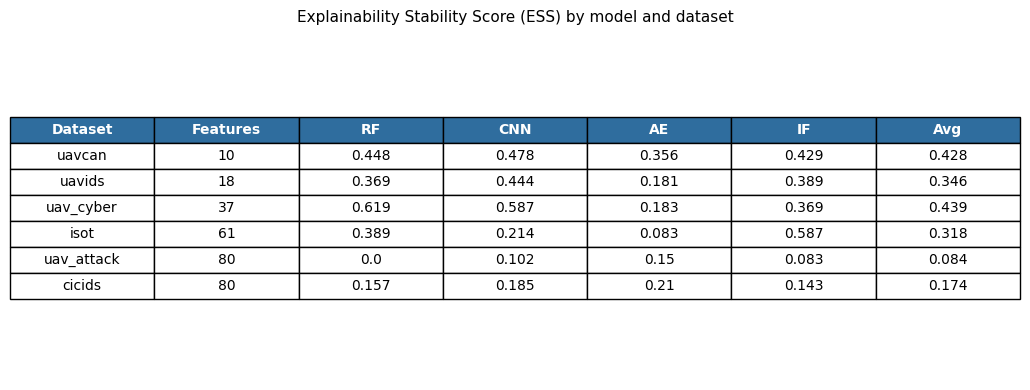

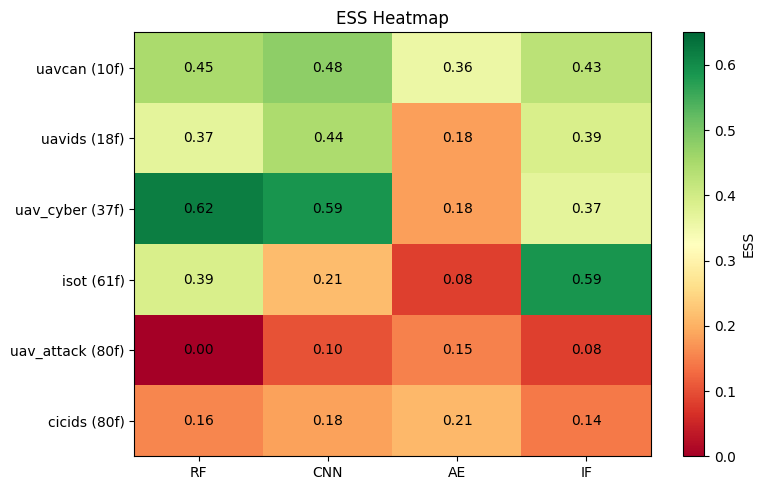


=== F1 TABLE ===
   Dataset  Features       RF      CNN       AE       IF
    uavcan        10 0.908476 0.887004 0.501064 0.473342
    uavids        18 0.952352 0.925198 0.850579 0.923281
 uav_cyber        37 0.992545 0.975008 0.023192 0.870353
      isot        61 0.999966 0.996257 0.980637 0.948607
uav_attack        80 1.000000 1.000000 0.902628 0.771654
    cicids        80 0.998641 0.978321 0.570515 0.510894


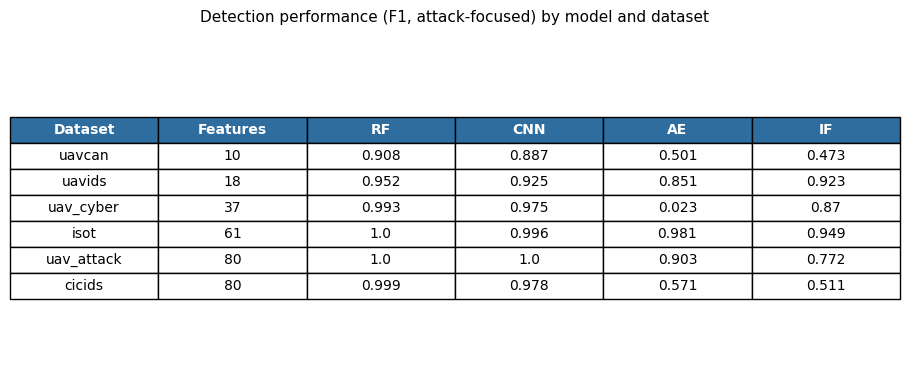

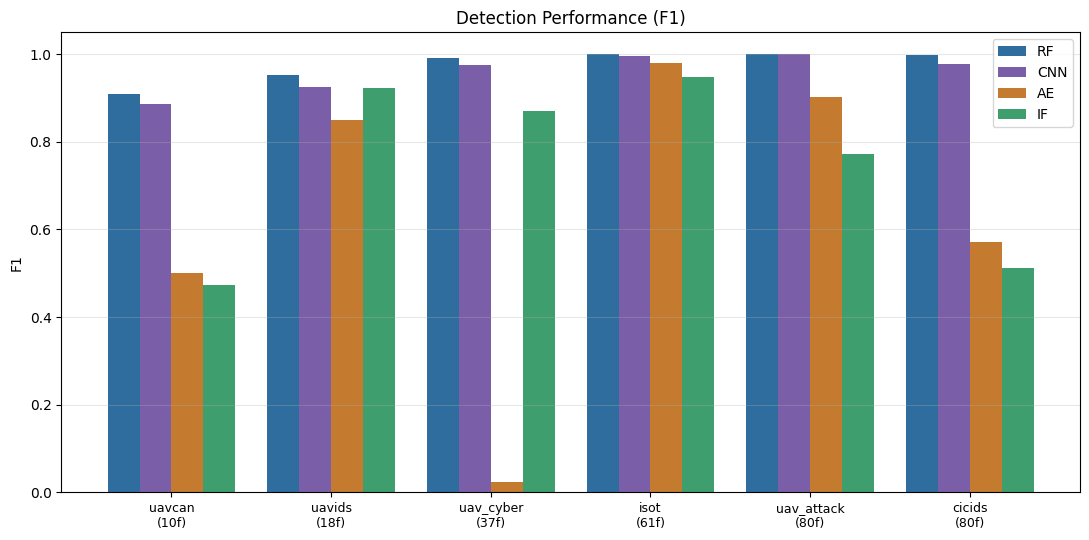


=== FINDING TABLE ===
   Dataset  Features  Avg ESS
    uavcan        10 0.427745
    uavids        18 0.345734
 uav_cyber        37 0.439484
      isot        61 0.318452
uav_attack        80 0.083829
    cicids        80 0.173776
Correlation: -0.851


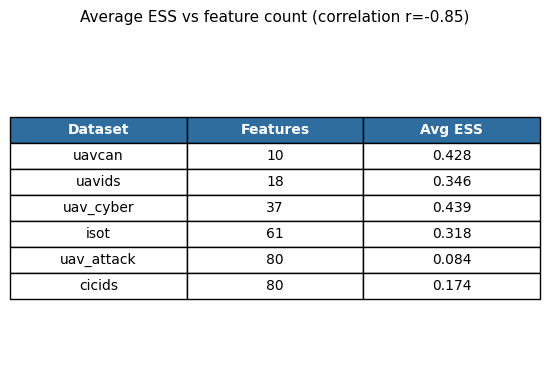

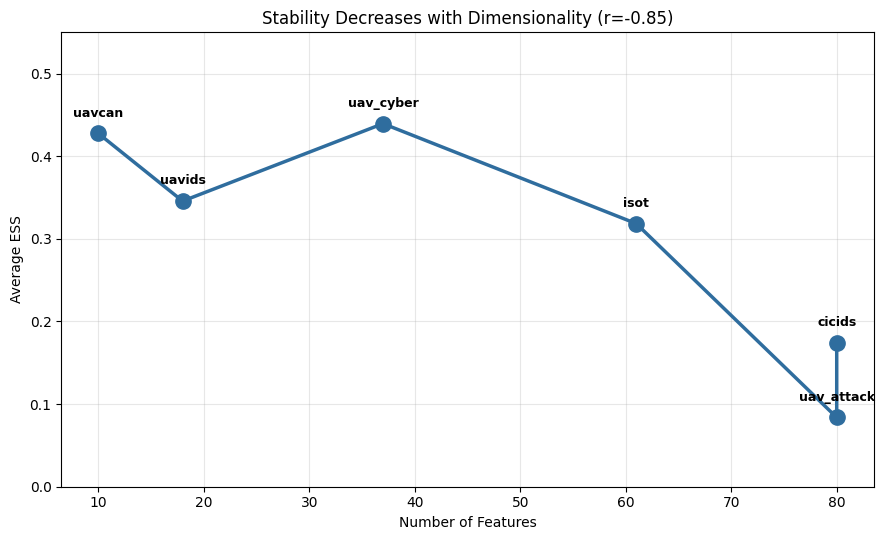


ALL EXPORTS SAVED to results/exports/
   ess.csv
   ess.tex
   ess_heatmap_chart.pdf
   ess_heatmap_chart.png
   ess_table.pdf
   ess_table.png
   f1.csv
   f1.tex
   f1_bars_chart.pdf
   f1_bars_chart.png
   f1_table.pdf
   f1_table.png
   finding.csv
   finding.tex
   finding_chart.pdf
   finding_chart.png
   finding_table.pdf
   finding_table.png


In [4]:
# COMPLETE EXPORT: every result as table (LaTeX + CSV + image) and chart (PNG + PDF).
# Everything saved to results/exports/ - ready for paper, UI, and slides.
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

datasets = ["uavcan", "uavids", "uav_cyber", "isot", "uav_attack", "cicids"]
models = ["rf", "cnn", "ae", "iso"]
mlabel = {"rf": "RF", "cnn": "CNN", "ae": "AE", "iso": "IF"}

data = {}
for ds in datasets:
    with open(f"results/results_{ds}.json") as f:
        data[ds] = json.load(f)
datasets.sort(key=lambda d: data[d]["n_features"])

out = "results/exports"
os.makedirs(out, exist_ok=True)

def export_table(df, name, caption):
    """Save a dataframe as CSV, LaTeX, and a table-image (png+pdf)."""
    # CSV
    df.to_csv(f"{out}/{name}.csv", index=False)
    # LaTeX
    with open(f"{out}/{name}.tex", "w") as f:
        f.write(df.to_latex(index=False, float_format="%.3f",
                            caption=caption, label=f"tab:{name}"))
    # table as image
    fig, ax = plt.subplots(figsize=(min(12, 1.2*len(df.columns)+2), 0.5*len(df)+1))
    ax.axis("off")
    t = ax.table(cellText=df.round(3).values, colLabels=df.columns,
                 cellLoc="center", loc="center")
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.4)
    # header styling
    for j in range(len(df.columns)):
        t[0, j].set_facecolor("#2f6d9e"); t[0, j].set_text_props(color="white", fontweight="bold")
    plt.title(caption, fontsize=11, pad=10)
    plt.tight_layout()
    plt.savefig(f"{out}/{name}_table.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{out}/{name}_table.pdf", bbox_inches="tight")
    plt.show()

def save_chart(name):
    plt.savefig(f"{out}/{name}.png", dpi=150, bbox_inches="tight")
    plt.savefig(f"{out}/{name}.pdf", bbox_inches="tight")

# ============================================================
# 1. ESS
# ============================================================
ess_rows = []
for ds in datasets:
    r = {"Dataset": ds, "Features": data[ds]["n_features"]}
    vals = []
    for m in models:
        v = data[ds]["ess"][m]["ess"]
        r[mlabel[m]] = v if v is not None else np.nan
        if v is not None: vals.append(v)
    r["Avg"] = np.mean(vals)
    ess_rows.append(r)
ess_df = pd.DataFrame(ess_rows)
print("=== ESS TABLE ==="); print(ess_df.to_string(index=False))
export_table(ess_df, "ess", "Explainability Stability Score (ESS) by model and dataset")

# ESS heatmap chart
ess_mat = ess_df[[mlabel[m] for m in models]].values
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ess_mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=0.65)
ax.set_xticks(range(len(models))); ax.set_xticklabels([mlabel[m] for m in models])
ax.set_yticks(range(len(datasets))); ax.set_yticklabels([f"{ds} ({data[ds]['n_features']}f)" for ds in datasets])
for i in range(len(datasets)):
    for j in range(len(models)):
        if not np.isnan(ess_mat[i,j]): ax.text(j, i, f"{ess_mat[i,j]:.2f}", ha="center", va="center")
ax.set_title("ESS Heatmap"); plt.colorbar(im, label="ESS"); plt.tight_layout()
save_chart("ess_heatmap_chart"); plt.show()

# ============================================================
# 2. F1
# ============================================================
f1_rows = []
for ds in datasets:
    r = {"Dataset": ds, "Features": data[ds]["n_features"]}
    for m in models: r[mlabel[m]] = data[ds]["ml_metrics"][m]["f1"]
    f1_rows.append(r)
f1_df = pd.DataFrame(f1_rows)
print("\n=== F1 TABLE ==="); print(f1_df.to_string(index=False))
export_table(f1_df, "f1", "Detection performance (F1, attack-focused) by model and dataset")

# F1 bars chart
fig, ax = plt.subplots(figsize=(11, 5.5)); x = np.arange(len(datasets)); w = 0.2
colors = ["#2f6d9e", "#7a5ea8", "#c47b2f", "#3f9e6e"]
for j, m in enumerate(models):
    ax.bar(x + j*w, f1_df[mlabel[m]].values, w, label=mlabel[m], color=colors[j])
ax.set_xticks(x + 1.5*w); ax.set_xticklabels([f"{ds}\n({data[ds]['n_features']}f)" for ds in datasets], fontsize=9)
ax.set_ylabel("F1"); ax.set_title("Detection Performance (F1)"); ax.legend(); ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.3); plt.tight_layout()
save_chart("f1_bars_chart"); plt.show()

# ============================================================
# 3. THE FINDING
# ============================================================
find_rows = []
for ds in datasets:
    vals = [data[ds]["ess"][m]["ess"] for m in models if data[ds]["ess"][m]["ess"] is not None]
    find_rows.append({"Dataset": ds, "Features": data[ds]["n_features"], "Avg ESS": np.mean(vals)})
find_df = pd.DataFrame(find_rows)
corr = np.corrcoef(find_df["Features"], find_df["Avg ESS"])[0,1]
print("\n=== FINDING TABLE ==="); print(find_df.to_string(index=False))
print(f"Correlation: {corr:.3f}")
export_table(find_df, "finding", f"Average ESS vs feature count (correlation r={corr:.2f})")

# finding line chart
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(find_df["Features"], find_df["Avg ESS"], "o-", color="#2f6d9e", linewidth=2.5, markersize=11)
for _, row in find_df.iterrows():
    ax.annotate(row["Dataset"], (row["Features"], row["Avg ESS"]),
                textcoords="offset points", xytext=(0,12), ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Number of Features"); ax.set_ylabel("Average ESS")
ax.set_title(f"Stability Decreases with Dimensionality (r={corr:.2f})")
ax.grid(True, alpha=0.3); ax.set_ylim(0, 0.55); plt.tight_layout()
save_chart("finding_chart"); plt.show()

# ============================================================
print("\n" + "="*60)
print("ALL EXPORTS SAVED to results/exports/")
print("="*60)
for f in sorted(os.listdir(out)):
    print("  ", f)